In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges (it's object type due to spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# One-hot encode remaining categoricals
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/tmp/ipykernel_55/537878124.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Logistic Regression AUC: 0.8416
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Random Forest AUC: 0.8204


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:49:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.8452


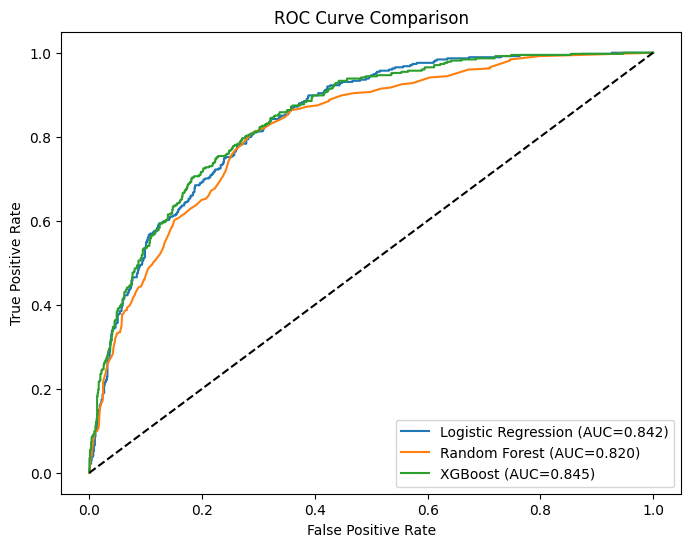

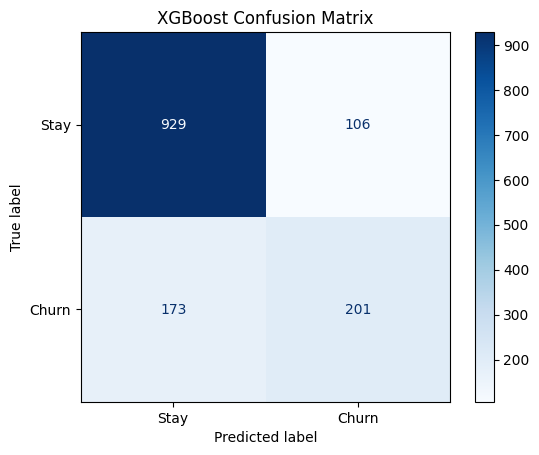

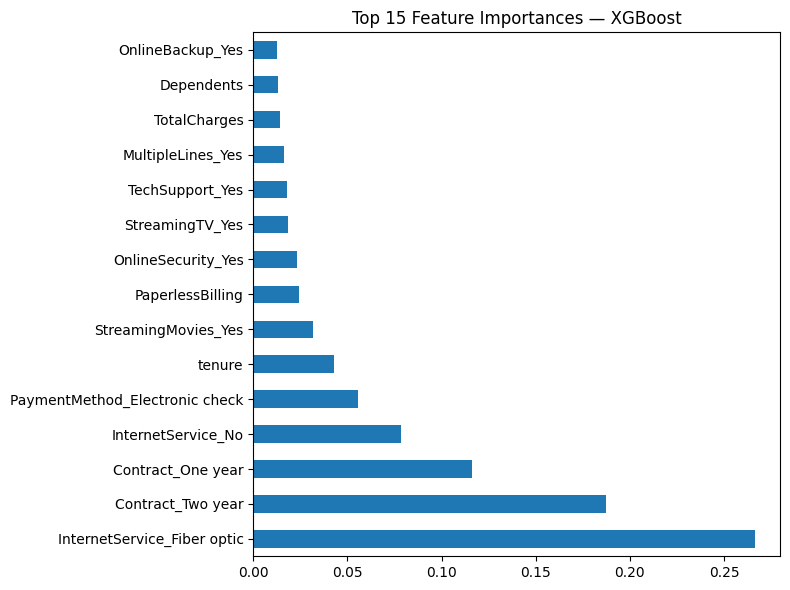

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# ── 1. Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(classification_report(y_test, lr_pred))

# ── 2. Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest AUC: {rf_auc:.4f}")

# ── 3. XGBoost ──
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
print(f"XGBoost AUC: {xgb_auc:.4f}")

# ── ROC Curve (all 3 models) ──
plt.figure(figsize=(8,6))
for model, name in [(lr,'Logistic Regression'),
                    (rf,'Random Forest'),
                    (xgb,'XGBoost')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

# ── Confusion Matrix (best model) ──
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stay','Churn'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# ── Feature Importance (XGBoost) ──
feat_imp = pd.Series(xgb.feature_importances_,
                     index=pd.DataFrame(X).columns if hasattr(X,'columns')
                     else range(X_train.shape[1]))
feat_imp.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=150)
plt.show()

In [4]:
import joblib

# Save model
joblib.dump(xgb, '/kaggle/working/xgb_churn_model.pkl')
joblib.dump(scaler, '/kaggle/working/scaler.pkl')

print("Saved!")

Saved!


In [5]:
import pandas as pd
import joblib

# Load model and scaler
model = joblib.load('/kaggle/working/xgb_churn_model.pkl')
scaler = joblib.load('/kaggle/working/scaler.pkl')

# Example new customer
new_customer = pd.DataFrame({
    'gender': [1],                  # 1=Male, 0=Female
    'SeniorCitizen': [0],           # 0=No, 1=Yes
    'Partner': [1],                 # 1=Yes, 0=No
    'Dependents': [0],              # 0=No, 1=Yes
    'tenure': [2],                  # 2 months — high churn risk
    'PhoneService': [1],            # 1=Yes
    'PaperlessBilling': [1],        # 1=Yes
    'MonthlyCharges': [85.50],      # High charges — churn risk
    'TotalCharges': [171.0],
    # One-hot encoded columns (from get_dummies)
    'MultipleLines_No phone service': [0],
    'MultipleLines_Yes': [1],
    'InternetService_Fiber optic': [1],
    'InternetService_No': [0],
    'OnlineSecurity_No internet service': [0],
    'OnlineSecurity_Yes': [0],
    'OnlineBackup_No internet service': [0],
    'OnlineBackup_Yes': [0],
    'DeviceProtection_No internet service': [0],
    'DeviceProtection_Yes': [0],
    'TechSupport_No internet service': [0],
    'TechSupport_Yes': [0],
    'StreamingTV_No internet service': [0],
    'StreamingTV_Yes': [1],
    'StreamingMovies_No internet service': [0],
    'StreamingMovies_Yes': [1],
    'Contract_One year': [0],
    'Contract_Two year': [0],       # Month-to-month = high risk
    'PaymentMethod_Credit card (automatic)': [0],
    'PaymentMethod_Electronic check': [1],  # Electronic check = high churn
    'PaymentMethod_Mailed check': [0],
})

# Scale and predict
new_scaled = scaler.transform(new_customer)
prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)[:,1]

print(f"Churn Prediction: {'YES - Will Churn' if prediction[0]==1 else 'NO - Will Stay'}")
print(f"Churn Probability: {probability[0]:.2%}")

Churn Prediction: YES - Will Churn
Churn Probability: 84.95%


In [6]:
customers = pd.DataFrame({
    'gender':           [1, 0],
    'SeniorCitizen':    [0, 1],
    'Partner':          [1, 0],
    'Dependents':       [0, 1],
    'tenure':           [2, 60],      # 2 months vs 5 years
    'PhoneService':     [1, 1],
    'PaperlessBilling': [1, 0],
    'MonthlyCharges':   [85.50, 45.0],# High vs low charges
    'TotalCharges':     [171.0, 2700.0],
    'MultipleLines_No phone service':       [0, 0],
    'MultipleLines_Yes':                    [1, 0],
    'InternetService_Fiber optic':          [1, 0],
    'InternetService_No':                   [0, 0],
    'OnlineSecurity_No internet service':   [0, 0],
    'OnlineSecurity_Yes':                   [0, 1],
    'OnlineBackup_No internet service':     [0, 0],
    'OnlineBackup_Yes':                     [0, 1],
    'DeviceProtection_No internet service': [0, 0],
    'DeviceProtection_Yes':                 [0, 1],
    'TechSupport_No internet service':      [0, 0],
    'TechSupport_Yes':                      [0, 1],
    'StreamingTV_No internet service':      [0, 0],
    'StreamingTV_Yes':                      [1, 0],
    'StreamingMovies_No internet service':  [0, 0],
    'StreamingMovies_Yes':                  [1, 0],
    'Contract_One year':                    [0, 0],
    'Contract_Two year':                    [0, 1],  # Two year = low risk
    'PaymentMethod_Credit card (automatic)':[0, 1],
    'PaymentMethod_Electronic check':       [1, 0],
    'PaymentMethod_Mailed check':           [0, 0],
})

scaled = scaler.transform(customers)
probs = model.predict_proba(scaled)[:,1]

for i, prob in enumerate(probs):
    print(f"Customer {i+1}: Churn Probability = {prob:.2%} "
          f"→ {'HIGH RISK ' if prob > 0.5 else 'LOW RISK '}")

Customer 1: Churn Probability = 84.95% → HIGH RISK 
Customer 2: Churn Probability = 2.11% → LOW RISK 
